In [ ]:
!pip install kagglehub

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/msambare/fer2013


In [2]:
import os
print(os.listdir(path))

['test', 'train']


In [3]:
import torch
from torchvision.datasets import ImageFolder
from torchvision.transforms import v2
from torch.utils.data import DataLoader, Subset
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim

In [4]:
base_transform=[
        v2.Grayscale(num_output_channels=1),
        v2.ToImage(),
        v2.ToDtype(torch.float32,scale=True),
        v2.Normalize(mean=[0.5],std=[0.5]),
        v2.Resize((48,48))
]

In [ ]:
train_transform=v2.Compose(base_transform+[v2.RandomHorizontalFlip(p=0.5)]+
[v2.RandomAffine(degrees=(-15,15),translate=(0.1,0.1))]+
[v2.RandomResizedCrop(48,scale=(0.8,1.0))])
test_transform=v2.Compose(base_transform)

In [6]:
from sklearn.model_selection import StratifiedShuffleSplit # this is for a balanced split
train_dataset_full=ImageFolder(root="/kaggle/input/datasets/msambare/fer2013/train",transform=train_transform)
val_dataset_full=ImageFolder(root="/kaggle/input/datasets/msambare/fer2013/train",transform=test_transform)
test_dataset_full=ImageFolder(root="/kaggle/input/datasets/msambare/fer2013/test",transform=test_transform)

sss=StratifiedShuffleSplit(n_splits=1,test_size=0.1,random_state=42)

full_targets=np.array(train_dataset_full.targets)

# Corrected: Pass a 1D array of the correct length for X
for train_idx, val_idx in sss.split(np.zeros(len(full_targets)),full_targets):
  train_indices=train_idx
  val_indices=val_idx

train_dataset=Subset(train_dataset_full,train_indices)
val_dataset=Subset(val_dataset_full,val_indices)

In [7]:
train_loader=DataLoader(train_dataset,batch_size=64,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=64,shuffle=True)
test_loader=DataLoader(test_dataset_full,batch_size=64,shuffle=True)

In [8]:
from collections import Counter
labels=train_loader.dataset.dataset.targets
counts=Counter(labels)
print(counts) # ba demeli 1 ci classdan 436 denedi demeli imbalanced-di indi duzeldejem
weights=[len(labels)/counts[i] for i in counts]
weights

Counter({3: 7215, 4: 4965, 5: 4830, 2: 4097, 0: 3995, 6: 3171, 1: 436})


[7.186232790988736,
 65.84633027522936,
 7.007322431047108,
 3.979071379071379,
 5.782275931520645,
 5.943892339544513,
 9.053610848312836]

In [9]:
# Check if everything is allright till this point (firstly load the images and labels)
train_images,train_labels=next(iter(train_loader))

In [10]:
print(f"The appearance of tensor = {train_images[0]}")
print(f"Min value = {train_images[0].min()}")
print(f"Max value = {train_images[0].max()}")
# The two above is just for training check, i didnt include test and val (cuz i dont want to)
print(f"Mean value across a batch in train dataset = {train_images.mean()}")
print(f"Shape of the batch = {train_images.shape}")
print(f"Labels in the first batch of train dataset = {np.unique(train_labels)}")

The appearance of tensor = tensor([[[-0.5216, -0.6172, -0.6587,  ..., -0.9137, -0.9142, -0.9216],
         [-0.4951, -0.6031, -0.6632,  ..., -0.9203, -0.9208, -0.9282],
         [-0.4438, -0.6357, -0.6527,  ..., -0.9274, -0.9275, -0.9294],
         ...,
         [-0.2116, -0.1802, -0.3109,  ..., -0.8333, -0.7585, -0.7315],
         [-0.2245, -0.3288, -0.5466,  ..., -0.7544, -0.7560, -0.8824],
         [-0.3569, -0.5480, -0.7716,  ..., -0.7964, -0.8676, -0.8824]]])
Min value = -0.9509038329124451
Max value = 0.943254828453064
Mean value across a batch in train dataset = 0.05864014849066734
Shape of the batch = torch.Size([64, 1, 48, 48])
Labels in the first batch of train dataset = [0 1 2 3 4 5 6]


In [11]:
# Vizualization
images,labels=next(iter(train_loader))
emotions=train_dataset.dataset.classes
emotions

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

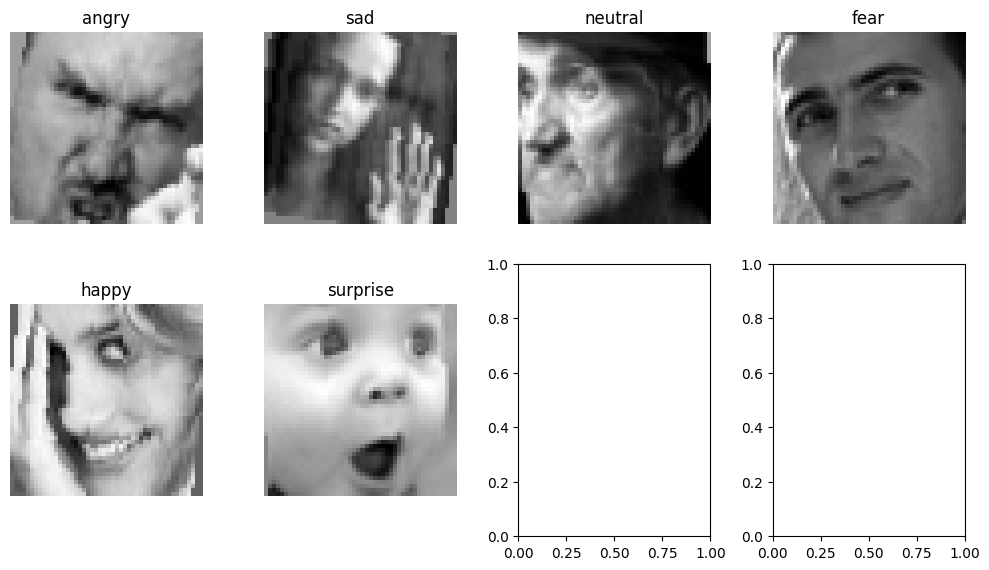

In [12]:
unique_emotions={} # using dict to catch unique emtotions in the first batch
for i in range(len(labels)):
  emotion_label=labels[i]
  emotion_name=emotions[emotion_label]

  if emotion_name not in unique_emotions:
    unique_emotions[emotion_name]=images[i].squeeze() # using squeeze to delete the additional channel dimension

  if len(unique_emotions)==len(emotions):
    break

fig,axes=plt.subplots(2,4,figsize=(10,6))
axes=axes.flatten()

for idx,(emotion,image) in enumerate(unique_emotions.items()):
  image=image*0.5+0.5
  axes[idx].imshow(image,cmap="grey")
  axes[idx].set_title(emotion)
  axes[idx].axis("off")
plt.tight_layout()
plt.show()
# The thing that every batch doesnt contain all the emotions, we cant see all of them

In [13]:
class Emote_detector(nn.Module):
  def __init__(self):
    super().__init__()

    # Block 1
    self.block1=nn.Sequential(
        nn.Conv2d(in_channels=1,out_channels=64,kernel_size=3,stride=1,padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)
    )
    # Block 2
    self.block2=nn.Sequential(
        nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,padding=1,stride=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)
    )
    # Block 3
    self.block3=nn.Sequential(
        nn.Conv2d(in_channels=128,out_channels=256,kernel_size=3,padding=1,stride=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)
    )
    # Decision Block
    self.classifier=nn.Sequential(
        # nn.AdaptiveAvgPool2d((1,1)),  the model started to underfit cuz of this so for now removed it
        nn.Flatten(),
        nn.Linear(in_features=256*6*6,out_features=256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(p=0.5),
        nn.Linear(in_features=256,out_features=7)
    )

  def forward(self,x):
    x=self.block1(x)
    x=self.block2(x)
    x=self.block3(x)
    x=self.classifier(x)
    return x

In [14]:
# creating a dummy model for just testing
model=Emote_detector()
X=torch.randn(4,1,48,48)
pred=model(X)
print(f"Output shape = {pred.shape}")

Output shape = torch.Size([4, 7])


In [15]:

weights=torch.tensor(weights,dtype=torch.float32)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights=weights.to(device)
model=Emote_detector().to(device)
criterion=nn.CrossEntropyLoss(weight=weights)
optimizer=optim.Adam(model.parameters(),lr=0.001)
scheduler=optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

num_epoch=40

best_val_acc=0.0
early_stopping_patience=5
epochs_without_improvement=0

train_losses=[]
val_losses=[]
val_accuracies=[]

for epoch in range(num_epoch):

  model.train()
  running_train_loss=0.0

  for images,labels in train_loader:
    images=images.to(device)
    labels=labels.to(device)

    outputs=model(images)
    loss=criterion(outputs,labels) # will return the mean value (it is the cost function)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    running_train_loss+=loss.item()*images.size(0)

  epoch_train_loss=running_train_loss/len(train_loader.dataset)
  train_losses.append(epoch_train_loss)

  model.eval()
  running_val_loss=0.0
  correct=0
  total=0

  with torch.no_grad():

    for images,labels in val_loader:
      images=images.to(device)
      labels=labels.to(device)

      outputs=model(images)
      loss=criterion(outputs,labels)

      running_val_loss+=loss.item()*images.size(0)
      _,preds=torch.max(outputs,1)
      correct+=(preds==labels).sum().item()
      total+=images.size(0)

    epoch_val_loss=running_val_loss/len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    epoch_val_accuracy=100*correct/total
    scheduler.step(epoch_val_accuracy)
    if epoch_val_accuracy>best_val_acc:
        best_val_acc=epoch_val_accuracy
        state_dict=model.state_dict().copy()
        epochs_without_improvement=0
    else:
        epochs_without_improvement+=1

    if epochs_without_improvement>=early_stopping_patience:
        print("Early Stopping")
        stop=epoch
        break
    val_accuracies.append(epoch_val_accuracy)

  print(f"{epoch+1}/{num_epoch} | ",end="")
  print(f"Training Loss : {epoch_train_loss} ",end="")
  print(f"Validation Loss : {epoch_val_loss} ",end="")
  print(f"Validation Accuracy : {epoch_val_accuracy} ",end="")
  print()

print("Training complete (heleleleleleel)")


1/40 | Training Loss : 1.7906340617441119 Validation Loss : 1.5963828109025706 Validation Accuracy : 39.881574364332984 
2/40 | Training Loss : 1.5739111882612906 Validation Loss : 1.416302498563662 Validation Accuracy : 47.927551375827235 
3/40 | Training Loss : 1.4746636174874683 Validation Loss : 1.3971169289293626 Validation Accuracy : 47.37025426680599 
4/40 | Training Loss : 1.4216014203553562 Validation Loss : 1.3158510960340084 Validation Accuracy : 51.480320445837684 
5/40 | Training Loss : 1.3803162729143128 Validation Loss : 1.3185566348175852 Validation Accuracy : 50.714036920933474 
6/40 | Training Loss : 1.3082868390818185 Validation Loss : 1.2620591775584578 Validation Accuracy : 52.176941832114245 
7/40 | Training Loss : 1.2683552445822044 Validation Loss : 1.27633994645418 Validation Accuracy : 55.973528387321494 
8/40 | Training Loss : 1.2417896886397481 Validation Loss : 1.2262495292557611 Validation Accuracy : 55.13758272378962 
9/40 | Training Loss : 1.217209760835

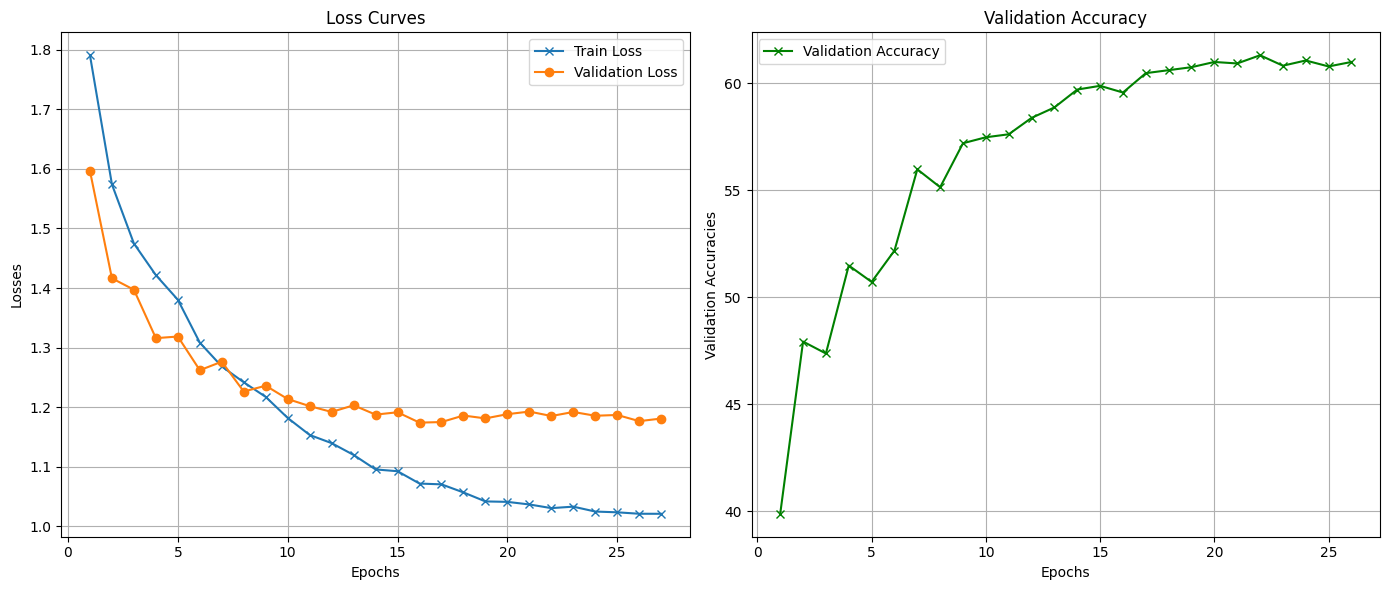

In [21]:
# plotting to see patterns (overfitting,underfitting etc)
fig,axes=plt.subplots(1,2,figsize=(14,6))
# Losses Plot
axes[0].plot(range(1,27+1),train_losses,marker="x",label="Train Loss")
axes[0].plot(range(1,27+1),val_losses,marker="o",label="Validation Loss")
axes[0].set_title("Loss Curves")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Losses")
axes[0].legend()
axes[0].grid(True)

# Accuracies Plot
axes[1].plot(range(1,27),val_accuracies,marker="x",label="Validation Accuracy", color='green')
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Validation Accuracies")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()